In [36]:
import pandas as pd

df = pd.read_csv('../datasets/redmi6.csv', encoding='windows-1252')

In [37]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
245,Don't buy this mobile mi 6 pro,Vasudevan,1.0 out of 5 stars,on 15 September 2018,Display,"Very poor quality in front facing camera, and ...",
81,Overall a nice phone,anant vasantrao bhamare,3.0 out of 5 stars,on 23 September 2018,Others,Sound quality is not so good\nEither way the m...,NaN
12,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
171,battery,Yaden Wap,5.0 out of 5 stars,on 1 October 2018,Others,daaaaaaaam good,NaN
149,Must buy,Amazon Customer,5.0 out of 5 stars,on 21 September 2018,Others,Great phone@,NaN
145,best phone in budget,mohammed imroz,5.0 out of 5 stars,on 28 September 2018,Others,awosome phone,NaN
261,Don't buy camera quality extreme poor.,shivam p.,1.0 out of 5 stars,on 20 September 2018,Camera,I got this product today camera both front and...,
260,turn out amazing to be amazing worth it,Pranay chaudhari,5.0 out of 5 stars,on 26 September 2018,Camera,"the camera is good, phone is fast overall work...",2 people found this helpful
71,Ok,Prashanta KN,1.0 out of 5 stars,on 28 September 2018,Others,Ok,One person found this helpful
221,Got a defective one and requested for a replac...,Anoopcbose,1.0 out of 5 stars,on 22 September 2018,Display,Phone is really nice and good looking.\nI thin...,


In [38]:
df.isnull().sum()

# We don't use 'Useful' column, so no problem with missing values

Review Title       0
Customer name      0
Rating             0
Date               0
Category           0
Comments           0
Useful           170
dtype: int64

In [39]:
df['Rating'] = df['Rating'].str.split(' ', expand=True)[0]

In [40]:
df['Rating'].unique().tolist()

['4.0', '3.0', '5.0', '2.0', '1.0']

In [41]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
171,battery,Yaden Wap,5.0,on 1 October 2018,Others,daaaaaaaam good,NaN
215,Ni,Amazon Customer,1.0,on 2 October 2018,Others,No,NaN
155,"Good, very good",Bivash das,5.0,on 22 September 2018,Others,Good product Amazon,NaN
244,"Very Terrible, Worst Smartphone.",Aniket Sidanale,1.0,on 19 September 2018,Camera,"Looks is poor. Very bad Performance, Camera qu...",
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
183,Looking smart,SUJEET KUMAR,4.0,on 22 September 2018,Others,Good,NaN
143,waste of money,Rameez Rashid Parray,1.0,on 29 September 2018,Others,waste of money,NaN
234,"Very Terrible, Worst Smartphone.",Aniket Sidanale,1.0,on 19 September 2018,Camera,"Looks is poor. Very bad Performance, Camera qu...",NaN
256,It Hangs,Ranjeet,1.0,on 1 October 2018,Others,"After using it for 10 days, I am writing it, t...",NaN
50,Best Mobile in this price category.,Rahul.K.R,4.0,on 2 October 2018,Battery,"Nice mobile, battery backup is good, camera gu...",One person found this helpful


In [42]:
df = df[['Rating', 'Comments', 'Category']]

In [43]:
# Check for missing values

df.isnull().sum()

Rating      0
Comments    0
Category    0
dtype: int64

In [44]:
df.sample(10)

,Rating,Comments,Category
131,5.0,Excellent mobile good display quality,Display
205,5.0,good,Others
191,5.0,Nice mobile,Others
254,5.0,Bettary so good,Others
36,4.0,Nice product. Delivery guy also.,Delivery
85,5.0,"Best phone with notch Display ,Battery Backup,...",Display
41,5.0,"Great product, fully met my expectations....",Others
18,5.0,Wooo,Others
112,4.0,I didn't get 500/- discount . Buy through HDFC...,Others
23,1.0,Please don't buy these product.. I have 3-mobi...,Others


In [45]:
df.count()

Rating      280
Comments    280
Category    280
dtype: int64

In [46]:
# This code is used to categorize comments into different sentiment categories using the Ollama API (with qwen2.5-coder:latest model).

from tqdm import tqdm
import ollama
import time

# Add a progress bar
for i in tqdm(range(len(df)), desc="Processing comments"):
    comment = df.loc[i, 'Comments']
    comment_category = 'Unknown'

    try:
        response = ollama.generate(
            model='qwen2.5-coder:latest',  
            prompt=f"Categorize the following comment into exactly one of these categories: Very Negative, Negative, Neutral, Positive, Very Positive. Comment: {comment}"
        )
        
        result = response['response'].strip()
        if result in ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']:
            comment_category = result
            
    except Exception as e:
        print(f"Error processing comment {i}: {str(e)}")
        
    df.loc[i, 'Comment Categories'] = comment_category
    
    # Add a small delay to avoid overwhelming the API
    time.sleep(0.1)

Processing comments:   0%|          | 0/280 [00:00<?, ?it/s]

Processing comments: 100%|██████████| 280/280 [06:47<00:00,  1.46s/it]


In [47]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
dtype: int64

In [48]:
df['Comment Categories'].unique().tolist()

['Unknown',
 'Negative',
 'Positive',
 'Neutral',
 'Very Negative',
 'Very Positive']

In [49]:
# Only load data that Comment Category equals to 'Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive', avoid 'Unknown' 
df = df[df['Comment Categories'].isin(['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])]

In [50]:
df['Comment Categories'].unique().tolist()

['Negative', 'Positive', 'Neutral', 'Very Negative', 'Very Positive']

In [51]:
df.sample(10)

,Rating,Comments,Category,Comment Categories
110,4.0,Camera is good,Camera,Positive
247,1.0,"Worst, don't go for it. Performance wise, came...",Battery,Very Negative
155,5.0,Good product Amazon,Others,Positive
70,5.0,Powerful device I love mi ...thnax Amazon for ...,Delivery,Positive
41,5.0,"Great product, fully met my expectations....",Others,Positive
16,4.0,Pros:\nnotch display\nDual camera\nFace unlock...,Display,Positive
227,5.0,Hey guys this is TECHBORED! and this is unboxi...,Display,Positive
123,5.0,Good quality,Others,Positive
29,5.0,Good phone at such a valuable price. Notch dis...,Display,Positive
27,3.0,Camera clarity is not good and average mobile ...,Camera,Negative


In [52]:
df.count()

Rating                258
Comments              258
Category              258
Comment Categories    258
dtype: int64

In [53]:
# Change data type
df.loc[:,'Rating'] = df['Rating'].astype(float)

In [54]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'}) 

In [56]:
df


,Rating,Comments,Category,Comment Categories,Rating Categories
1,3.0,All ok but vry small size mobile,Others,Negative,Neutral
2,3.0,Quite good,Others,Positive,Neutral
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative,Negative
6,4.0,Pros:\nnotch display\nDual camera\nFace unlock...,Display,Positive,Positive
7,4.0,Front camera is poor rest things are good,Camera,Negative,Positive
...,...,...,...,...,...
274,3.0,Nice product\nFront or rear camera thoda accha...,Camera,Negative,Neutral
275,5.0,"I like This Phone, Awesome look and design.\nI...",Others,Positive,Very Positive
276,4.0,Product is avasome but invoice is note include...,Others,Negative,Positive
278,5.0,I love mi,Others,Positive,Very Positive


In [57]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [58]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

               Rating Categories Count  Comment Categories Count
Very Positive                      148                         1
Positive                            44                       170
Very Negative                       35                        16
Neutral                             23                        15
Negative                             8                        56


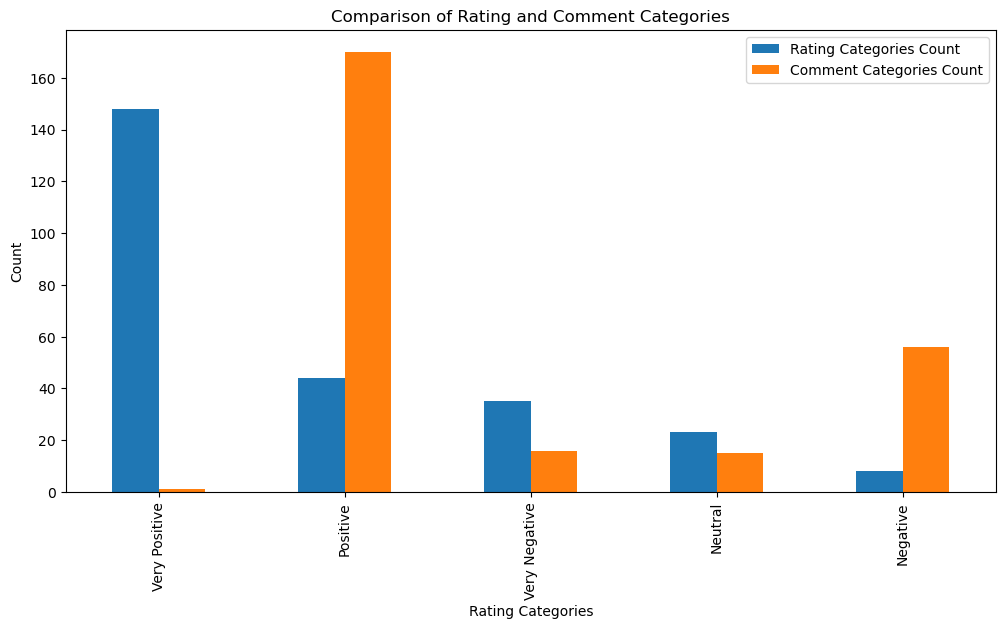

In [59]:
import matplotlib.pyplot as plt

# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [60]:
# Get the mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 201


In [62]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

In [63]:
# Do mapping Comment Categories
df.loc[:, 'Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'})

In [64]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [65]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

          Rating Categories Count  Comment Categories Count
Positive                      192                       171
Negative                       43                        72
Neutral                        23                        15


In [66]:
# Get mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 51


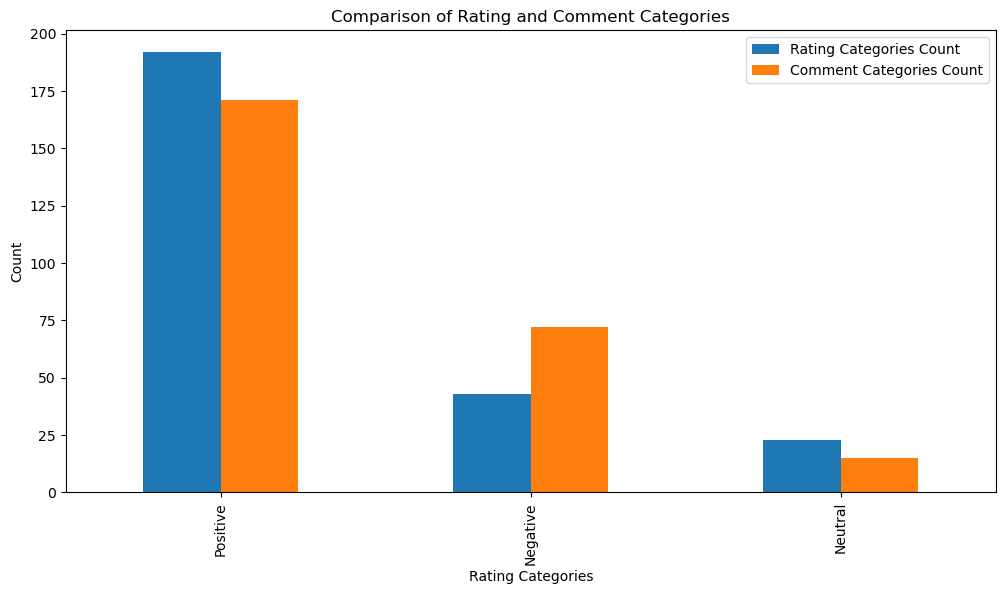

In [67]:
# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

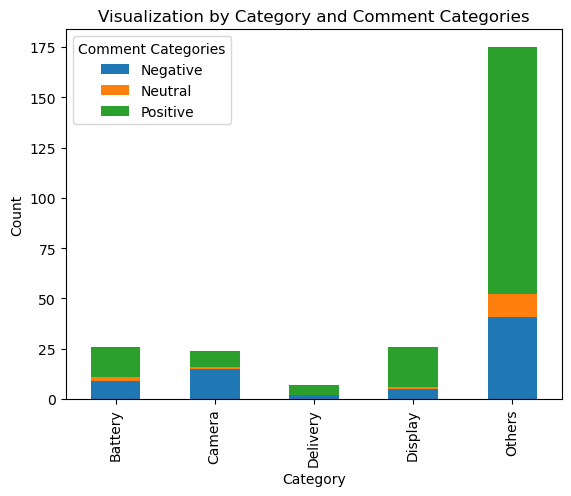

In [68]:
# Create pivot table
pivot_table = df.pivot_table(index='Category', columns='Comment Categories', aggfunc='size', fill_value=0)

# Display the pivot table
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Visualization by Category and Comment Categories')
plt.show()

In [31]:
df

,Rating,Comments,Category,Comment Categories,Rating Categories
1,3.0,All ok but vry small size mobile,Others,Negative,Neutral
2,3.0,Quite good,Others,Positive,Neutral
3,5.0,Redmi has always have been the the king of bud...,Display,Positive,Positive
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative,Negative
6,4.0,Pros:\nnotch display\nDual camera\nFace unlock...,Display,Positive,Positive
...,...,...,...,...,...
274,3.0,Nice product\nFront or rear camera thoda accha...,Camera,Negative,Neutral
275,5.0,"I like This Phone, Awesome look and design.\nI...",Others,Positive,Positive
276,4.0,Product is avasome but invoice is note include...,Others,Positive,Positive
277,3.0,"Redmi Note4, Note5, now 6pro..It seems the old...",Battery,Negative,Neutral
